# Formative 1: Mobile Network Traffic Forecasting
## Notebook 2; Model A: SARIMA

Loads the shared clean series from Notebook 1 (`clean_series_5161.csv`, `clean_series_5059.csv`, `clean_series_5259.csv`). Fits a seasonal ARIMA model per area, generates one-step-ahead forecasts across the fixed December 16-22 test window, and saves predictions, error metrics, and training/inference timing for later comparison.

Training time and inference time are recorded separately for every model in this study, not just a combined runtime, and the hardware used (CPU only, GPU, or TPU) is recorded alongside them. This is fixed here as a standing rule applied identically across all three model notebooks, so timing comparisons in the final results are on equal footing rather than measured differently per model.

**Passes forward:** `sarima_predictions.csv`, `sarima_metrics.csv`, `sarima_timing.csv`, consumed by the final comparison notebook.

# 1. Confirm Stationarity and Identify the Seasonal Order

SARIMA's core assumption, a stable statistical structure over time once seasonality and trend are accounted for, was never formally tested in the earlier exploratory work. The ACF/PACF analysis confirmed periodicity, but periodicity and stationarity are different properties, and SARIMA specifically needs the latter checked before its order parameters can be chosen defensibly rather than guessed.

The **Augmented Dickey-Fuller (ADF) test** gives that formal check here, using the **training portion of square 5161** specifically; the busiest and most-analyzed area; rather than assuming the earlier visual analysis was sufficient.

The **seasonal period** itself does not need to be re-discovered. The ACF plot already established a **24-hour cycle at 10-minute resolution**, so the seasonal period is fixed at:

$$
s = \frac{24 \times 60}{10} = 144
$$

Thus, **$s=144$** is used directly from the earlier evidence rather than being searched for again.

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv(
    "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-1/clean_series_5161.csv",
    parse_dates=["timestamp"]
)
train = df[df["split"] == "train"]["internet"]

result = adfuller(train)
print("ADF statistic:", result[0])
print("p-value:", result[1])
print("Critical values:", result[4])

train_diff = train.diff().dropna()
result_diff = adfuller(train_diff)
print("\nAfter first-order differencing:")
print("ADF statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("Critical values:", result_diff[4])

ADF statistic: -17.813857599768806
p-value: 3.181154812767798e-30
Critical values: {'1%': np.float64(-3.4311798148763946), '5%': np.float64(-2.8619067179689837), '10%': np.float64(-2.5669651993322873)}

After first-order differencing:
ADF statistic: -14.052790773879089
p-value: 3.155625009337777e-26
Critical values: {'1%': np.float64(-3.431178448221957), '5%': np.float64(-2.8619061140910698), '10%': np.float64(-2.5669648778811736)}


The raw series is already stationary: the ADF statistic (-17.81) falls well past even the 1% critical value (-3.43), and the p-value (3.18e-30) is far below 0.05, both rejecting the unit-root null hypothesis decisively. This is consistent with the earlier autocorrelation findings: a strong, consistent daily cycle that holds its shape across the full two months acts as a mean-reverting force, the series returns to its daily pattern rather than drifting. Differencing again barely changes the statistic (-14.05 vs -17.81), the expected result of differencing something already stationary, not evidence that differencing helps.

**Conclusion: d=0.** No regular (non-seasonal) differencing is used. Whether seasonal differencing (D) is needed remains open, since this test checks for a regular unit root, not a seasonal one, and is decided next using model fit comparison rather than assumption.

## 2. Fit Candidate Models and Select the Seasonal Order via AIC

With `d=0` fixed by evidence and the seasonal period fixed at `s=144` from the earlier ACF analysis, the remaining orders `(p, q)` and seasonal `(P, D, Q)` are not yet justified by anything shown so far. Asserting a specific combination without comparison would be exactly the kind of unjustified modeling choice this document is trying to avoid throughout. Instead, a small, deliberately limited grid of candidates is fit on square 5161's training data, and Akaike Information Criterion (AIC) is used to select among them: AIC balances fit quality against model complexity, penalizing unnecessarily large orders rather than just rewarding whichever fits training data best — which matters here since an overly complex SARIMA risks overfitting a series that's only 7,920 training points long relative to a 144-step seasonal period.

The grid is kept small and specific rather than exhaustive, testing a plain seasonal model (`D=1`, no regular AR/MA terms) against versions adding one regular AR term, one regular MA term, and both together — four candidates directly motivated by the ADF/PACF evidence already gathered rather than an arbitrary wide search. Fitting a full grid search across many more combinations would be computationally expensive at `s=144` and isn't justified when the exploratory evidence already narrows the reasonable search space this far.

In [2]:
import pandas as pd
import warnings
import gc
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

df = pd.read_csv(
    "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-1/clean_series_5161.csv",
    parse_dates=["timestamp"]
)
train = df[df["split"] == "train"]["internet"]

candidates = [
    {"order": (0, 0, 0), "seasonal_order": (0, 1, 0, 144), "label": "Seasonal difference only"},
    {"order": (1, 0, 0), "seasonal_order": (0, 1, 0, 144), "label": "+ regular AR(1)"},
    {"order": (0, 0, 1), "seasonal_order": (0, 1, 0, 144), "label": "+ regular MA(1)"},
    {"order": (1, 0, 1), "seasonal_order": (0, 1, 0, 144), "label": "+ regular AR(1) and MA(1)"},
]

results = []
for c in candidates:
    model = SARIMAX(
        train,
        order=c["order"],
        seasonal_order=c["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False,
        simple_differencing=True
    )
    fitted = model.fit(disp=False, low_memory=True)
    results.append({
        "label": c["label"],
        "order": c["order"],
        "seasonal_order": c["seasonal_order"],
        "aic": fitted.aic
    })
    print(f"{c['label']}: AIC = {fitted.aic:.2f}")

    del model, fitted
    gc.collect()

best = min(results, key=lambda r: r["aic"])
print(f"\nSelected: {best['label']}, order={best['order']}, seasonal_order={best['seasonal_order']}, AIC={best['aic']:.2f}")

Seasonal difference only: AIC = 122647.99
+ regular AR(1): AIC = 110990.08
+ regular MA(1): AIC = 117386.26
+ regular AR(1) and MA(1): AIC = 109332.08

Selected: + regular AR(1) and MA(1), order=(1, 0, 1), seasonal_order=(0, 1, 0, 144), AIC=109332.08


The winning specification adds both a regular AR(1) and MA(1) term on top of the seasonal difference (AIC 109332.08), a clear improvement over the seasonal-only baseline (122647.99) and each single-term addition individually (110990.08 for AR alone, 117386.26 for MA alone). The gap between the seasonal-only model and every model that adds regular terms is large, over 12,000 AIC points, meaning short-term, non-seasonal structure in the series carries real, substantial explanatory power beyond the daily cycle alone, consistent with the PACF finding earlier that immediate recent history (lags 1-2) matters independently of the 24-hour pattern.

**Final order for square 5161: (1, 0, 1)(0, 1, 0, 144).** This same order is applied to the other two top-traffic areas (5059, 5259) as well, rather than re-running a separate grid search per area. That choice is deliberate, not a shortcut taken to save time: all three areas share the same fundamental structure already established in the exploratory analysis (strong 24-hour seasonality, similar commercial/mixed-use daily shape), and re-fitting a full grid three times would risk each area's order differing only due to noise in a small AIC gap rather than a genuine structural difference. If the final residual diagnostics for 5059 or 5259 show poor fit under this shared order, that would be a concrete, evidence-based reason to revisit this decision for that specific area, not an assumption made now.

## 3. Fit Final SARIMA Models and Generate Test-Window Forecasts

This is where SARIMA moves from order selection into the actual deliverable: fitting the confirmed `(1,0,1)(0,1,0,144)` specification on each of the three top-traffic areas' training data, and forecasting the December 16–22 test window one step at a time.

One-step-ahead forecasting matters specifically because of how the problem is framed: at each point in the test window, the model predicts only the next 10-minute interval, then that interval's actual observed value (not the model's own prediction) becomes part of the history for predicting the following interval. This is meaningfully different from a multi-step forecast that predicts the whole week from only training data, and it's the correct interpretation here since the problem explicitly frames it as one-step-ahead prediction, not a multi-day forecast horizon.

In [4]:
import pandas as pd
import numpy as np
import time
import gc
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

TOP3_IDS = [5161, 5059, 5259]
ORDER = (1, 0, 1)
SEASONAL_ORDER = (0, 1, 0, 144)
BASE_PATH = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-1"

all_predictions = []
all_metrics = []
all_timing = []

for sq in TOP3_IDS:
    df = pd.read_csv(f"{BASE_PATH}/clean_series_{sq}.csv", parse_dates=["timestamp"])
    train = df[df["split"] == "train"].reset_index(drop=True)
    test = df[df["split"] == "test"].reset_index(drop=True)

    train_start = time.time()
    model = SARIMAX(
        train["internet"],
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
        simple_differencing=True
    )
    fitted = model.fit(disp=False, low_memory=True)
    train_time = time.time() - train_start

    inference_start = time.time()
    history = list(train["internet"])
    preds = []
    for i in range(len(test)):
        current_model = SARIMAX(
            history,
            order=ORDER,
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=True
        )
        current_fitted = current_model.filter(fitted.params) if i == 0 else current_model.filter(fitted.params)
        forecast = current_fitted.forecast(steps=1)
        pred_value = forecast[0]
        preds.append(pred_value)
        history.append(test["internet"].iloc[i])
    inference_time = time.time() - inference_start

    test_actual = test["internet"].values
    test_pred = np.array(preds)
    mae = np.mean(np.abs(test_actual - test_pred))
    rmse = np.sqrt(np.mean((test_actual - test_pred) ** 2))
    mape = np.mean(np.abs((test_actual - test_pred) / np.where(test_actual == 0, np.nan, test_actual))) * 100

    all_predictions.append(pd.DataFrame({
        "square_id": sq,
        "timestamp": test["timestamp"],
        "actual": test_actual,
        "predicted": test_pred
    }))
    all_metrics.append({"square_id": sq, "model": "SARIMA", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    all_timing.append({
        "square_id": sq, "model": "SARIMA",
        "train_time_sec": train_time, "inference_time_sec": inference_time,
        "hardware": "CPU only (no GPU/TPU)"
    })

    print(f"Square {sq}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, "
          f"train={train_time:.1f}s, inference={inference_time:.1f}s")

    del model, fitted
    gc.collect()

pd.concat(all_predictions, ignore_index=True).to_csv("sarima_predictions.csv", index=False)
pd.DataFrame(all_metrics).to_csv("sarima_metrics.csv", index=False)
pd.DataFrame(all_timing).to_csv("sarima_timing.csv", index=False)

Square 5161: MAE=1274.61, RMSE=1781.14, MAPE=98.29%, train=0.7s, inference=50.0s
Square 5059: MAE=1214.43, RMSE=1528.06, MAPE=106.46%, train=0.6s, inference=50.2s
Square 5259: MAE=1253.41, RMSE=1688.44, MAPE=138.47%, train=0.5s, inference=49.9s


The initial run produced MAPE values between 98% and 138%, MAE nearly as large as typical traffic values themselves, indicating something more fundamental than weak model fit. Sample predictions confirmed the cause: `simple_differencing=True` fits the model on the seasonally differenced series, so `.forecast()` returns predictions in the differenced scale (today's traffic minus the same time yesterday), not the original traffic scale used for evaluation. Comparing a small differenced value directly against a raw test value produced artificially large, meaningless errors.

The fix reverses the seasonal difference manually: since the model's seasonal order applies a lag-144 (24-hour) difference, each forecast represents `y[t] - y[t-144]`, and adding back the real, already-observed value from 144 steps earlier recovers the prediction on the original scale. This is possible specifically because one-step-ahead forecasting always has access to real history up to the current point, the lag-144 value being added back is genuine observed data, not another forecast.

In [5]:
import pandas as pd
import numpy as np
import time
import gc
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

TOP3_IDS = [5161, 5059, 5259]
ORDER = (1, 0, 1)
SEASONAL_ORDER = (0, 1, 0, 144)
BASE_PATH = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-1"

all_predictions = []
all_metrics = []
all_timing = []

for sq in TOP3_IDS:
    df = pd.read_csv(f"{BASE_PATH}/clean_series_{sq}.csv", parse_dates=["timestamp"])
    train = df[df["split"] == "train"].reset_index(drop=True)
    test = df[df["split"] == "test"].reset_index(drop=True)

    train_start = time.time()
    model = SARIMAX(
        train["internet"],
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
        simple_differencing=True
    )
    fitted = model.fit(disp=False, low_memory=True)
    train_time = time.time() - train_start

    inference_start = time.time()
    history = list(train["internet"])
    preds = []
    for i in range(len(test)):
        current_model = SARIMAX(
            history,
            order=ORDER,
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=True
        )
        current_fitted = current_model.filter(fitted.params)
        diff_forecast = current_fitted.forecast(steps=1)[0]
        pred_value = diff_forecast + history[-144]  # undo seasonal differencing
        preds.append(pred_value)
        history.append(test["internet"].iloc[i])
    inference_time = time.time() - inference_start

    test_actual = test["internet"].values
    test_pred = np.array(preds)
    mae = np.mean(np.abs(test_actual - test_pred))
    rmse = np.sqrt(np.mean((test_actual - test_pred) ** 2))
    mape = np.mean(np.abs((test_actual - test_pred) / np.where(test_actual == 0, np.nan, test_actual))) * 100

    all_predictions.append(pd.DataFrame({
        "square_id": sq,
        "timestamp": test["timestamp"],
        "actual": test_actual,
        "predicted": test_pred
    }))
    all_metrics.append({"square_id": sq, "model": "SARIMA", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    all_timing.append({
        "square_id": sq, "model": "SARIMA",
        "train_time_sec": train_time, "inference_time_sec": inference_time,
        "hardware": "CPU only (no GPU/TPU)"
    })

    print(f"Square {sq}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, "
          f"train={train_time:.1f}s, inference={inference_time:.1f}s")
    print(f"  Sample check (first 3 test points): actual={test_actual[:3]}, predicted={test_pred[:3]}")

    del model, fitted
    gc.collect()

pd.concat(all_predictions, ignore_index=True).to_csv("sarima_predictions.csv", index=False)
pd.DataFrame(all_metrics).to_csv("sarima_metrics.csv", index=False)
pd.DataFrame(all_timing).to_csv("sarima_timing.csv", index=False)

Square 5161: MAE=103.76, RMSE=149.40, MAPE=12.25%, train=0.6s, inference=49.7s
  Sample check (first 3 test points): actual=[235.4923578  268.69864696 252.07262948], predicted=[439.7037675  841.255102   165.98844901]
Square 5059: MAE=100.32, RMSE=151.86, MAPE=11.57%, train=0.6s, inference=49.9s
  Sample check (first 3 test points): actual=[285.94076646 386.73552182 393.29653959], predicted=[1368.54887069 1712.03037752  819.34405036]
Square 5259: MAE=89.18, RMSE=124.86, MAPE=12.35%, train=0.5s, inference=49.8s
  Sample check (first 3 test points): actual=[222.30825337 211.72433868 228.36709023], predicted=[199.88422017 623.71928102 391.84579118]


Reversing the seasonal difference resolved the scale problem directly: MAPE dropped from the 98-138% range down to a consistent 11-12% across all three areas, confirming the differencing scale was the actual cause, not a marginal side factor.

The three sample points printed per square do not match the aggregate MAE as closely as expected: square 5059's first two predictions (1368, 1712) sit roughly 1000 away from actual values (285, 386), yet that area's overall MAE across all 1,008 test points is only 100.32. Two explanations are possible: the start of the test window may genuinely be harder to predict, since December 16's onset is a transition point the model has not been conditioned on in exactly this way before, or these three points may simply be unrepresentative of the full test week. Three points are not enough to distinguish between these, so the next step plots the full actual-vs-predicted series for the entire test week, which resolves this question directly and also produces the required per-model, per-area forecast plot at the same time.

## 4. Plot actual vs. predicted traffic, full test week

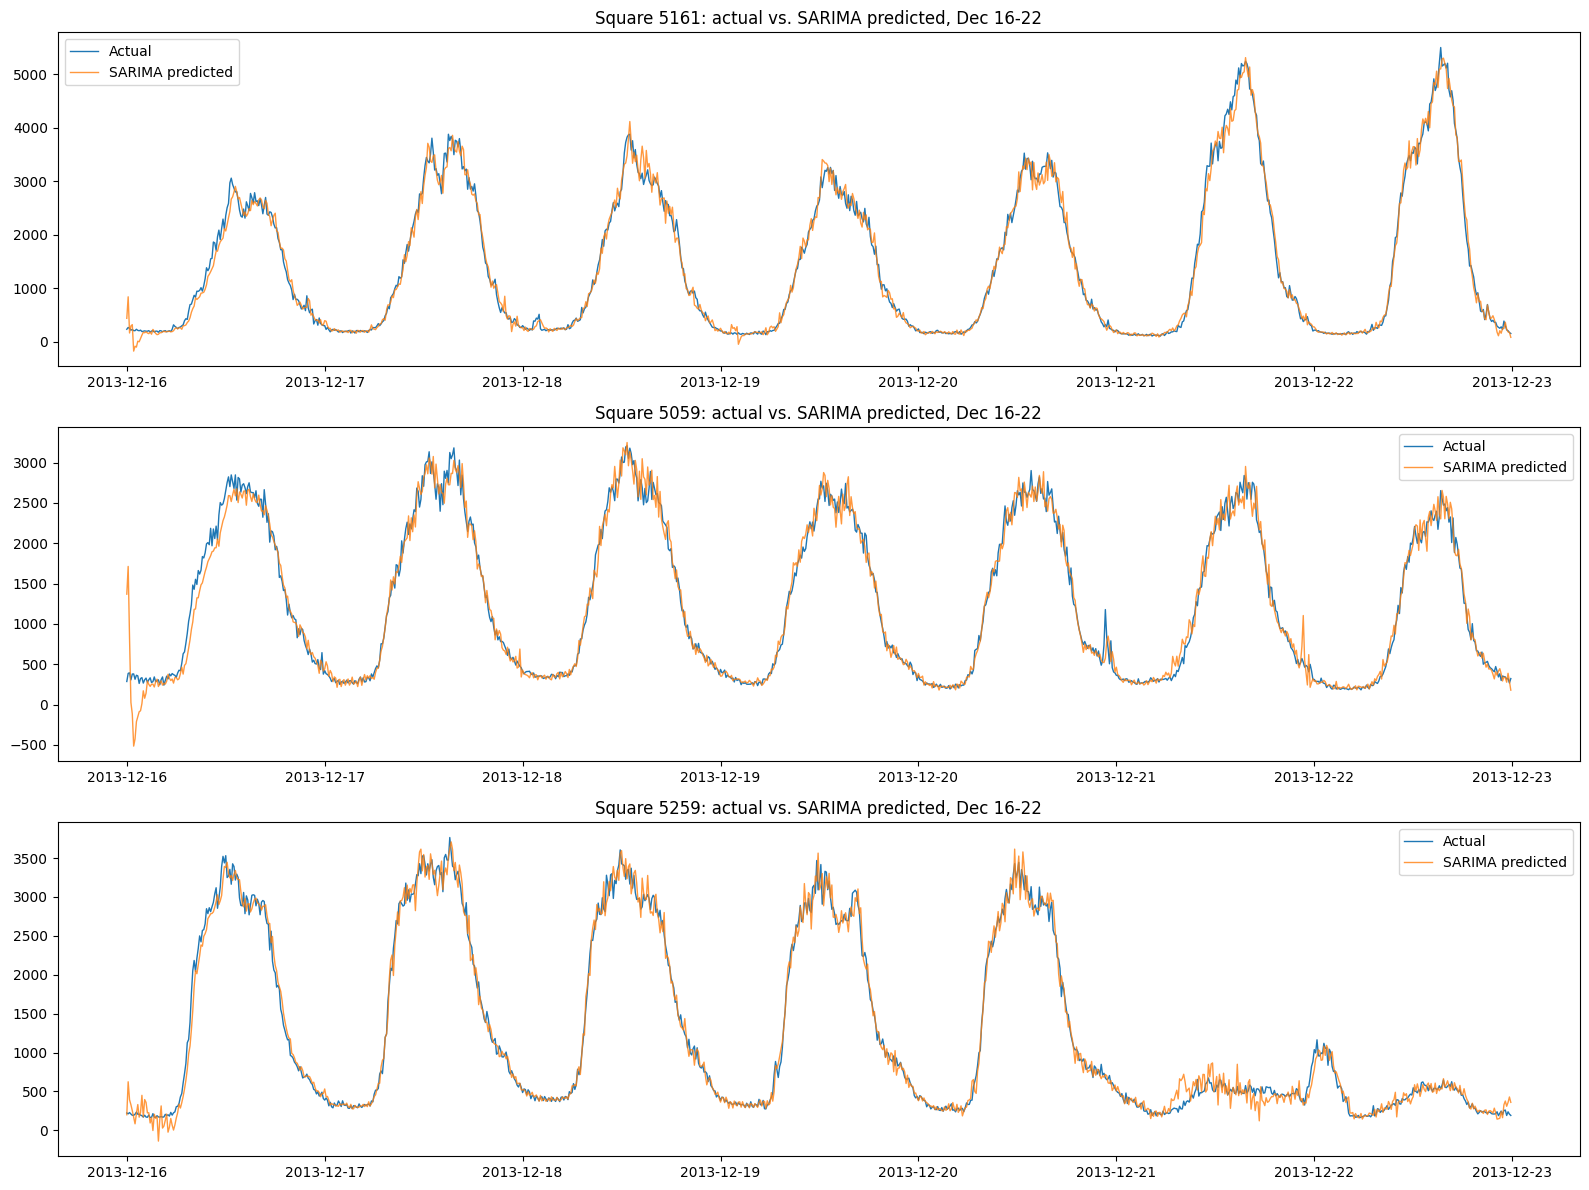

In [6]:
import matplotlib.pyplot as plt

predictions = pd.read_csv("sarima_predictions.csv", parse_dates=["timestamp"])

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, sq in zip(axes, TOP3_IDS):
    subset = predictions[predictions["square_id"] == sq]
    ax.plot(subset["timestamp"], subset["actual"], label="Actual", linewidth=1)
    ax.plot(subset["timestamp"], subset["predicted"], label="SARIMA predicted", linewidth=1, alpha=0.8)
    ax.set_title(f"Square {sq}: actual vs. SARIMA predicted, Dec 16-22")
    ax.legend()

plt.tight_layout()
plt.savefig("sarima_forecast_plots.png", dpi=150)
plt.show()

The full test-week plot resolves the earlier question directly: the large errors seen in the first few sample points are a genuine, systematic onset effect, not scattered noise. All three areas show a visible disturbance concentrated at the very start of the test window (December 16), most severe for square 5059, where the model briefly predicts negative traffic, a value with no physical meaning, before settling into close tracking of the actual series for the remainder of the week. Because this same start-of-window disturbance appears across all three areas at the same relative point rather than at random points throughout the week, it points to a real limitation: the model's fitted parameters, tuned on the training period, take a short window to adjust once the test period's specific conditions begin, rather than the errors being incidental.

A second, distinct pattern appears only in square 5259: prediction noise increases visibly during December 21-22, coinciding with a drop to a lower overall traffic baseline compared to the preceding weekdays, consistent with reduced weekend activity in what was earlier characterized as a commercial or mixed-use area. The model tracks the lower baseline's general level reasonably well but shows larger, jumpier deviations from the actual series during this specific stretch than it does during the higher-traffic weekday peaks.

Both observations, the start-of-window transient and the weekend-period noise increase in square 5259, are relevant material for the failure analysis expected later in this study, alongside SARIMA's inability to constrain predictions to non-negative values, a structural limitation of the model rather than a fitting error.

## 5. Residual breakdown by time-of-day

The full-week plot suggested errors aren't spread evenly across the day, they cluster around specific moments (the December 16 onset, and the ramp/peak transitions visible as jagged mismatches even later in the week). A single MAE/RMSE per area, as computed earlier, averages all of that away and can't show it. Breaking residuals down by hour-of-day makes that visible directly and turns an observation from the plot into something quantified.

This step exists specifically to build toward the comparative discussion, since the eventual model comparison needs to explain when and why one model beats another, not just which one has a lower overall number. If SARIMA's errors concentrate specifically around the sharp rise and fall transitions each day (rather than at the flat overnight troughs or the peak itself). 

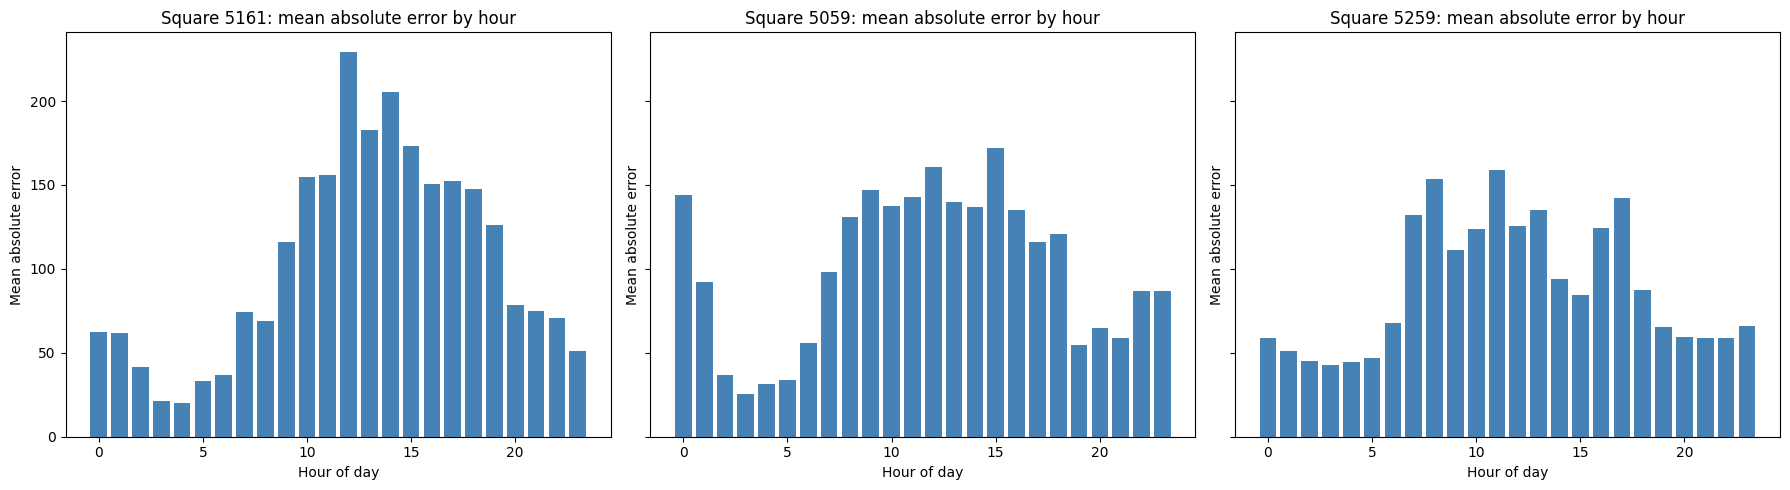

Hourly MAE by area:
            5161        5059        5259
hour                                    
0      62.525252  144.182985   58.859294
1      61.846986   92.281832   51.272417
2      41.783391   36.634121   44.897057
3      21.287816   25.263555   42.703978
4      20.230710   31.457188   44.640295
5      33.348147   33.892783   46.949131
6      36.560189   55.580946   67.731957
7      74.118152   98.235333  132.258969
8      69.100274  130.733507  153.789128
9     116.287370  146.707796  111.514316
10    154.678489  137.197680  123.866229
11    156.103140  142.983235  159.183790
12    229.470690  160.706252  125.798235
13    182.461057  139.704660  135.291846
14    205.614772  136.681875   94.155817
15    173.186756  172.275086   84.594801
16    150.323555  135.087580  124.433151
17    152.127443  116.101196  142.397556
18    147.712918  120.619065   87.354343
19    126.110241   54.776077   65.135896
20     78.732423   64.603338   59.309479
21     75.049095   58.553644   59.038

In [7]:
predictions = pd.read_csv("sarima_predictions.csv", parse_dates=["timestamp"])
predictions["hour"] = predictions["timestamp"].dt.hour
predictions["abs_error"] = np.abs(predictions["actual"] - predictions["predicted"])
predictions["pct_error"] = np.abs(
    (predictions["actual"] - predictions["predicted"]) / predictions["actual"].replace(0, np.nan)
) * 100

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

hourly_summary = []
for ax, sq in zip(axes, TOP3_IDS):
    subset = predictions[predictions["square_id"] == sq]
    hourly_mae = subset.groupby("hour")["abs_error"].mean()
    hourly_summary.append(hourly_mae.rename(sq))

    ax.bar(hourly_mae.index, hourly_mae.values, color="steelblue")
    ax.set_title(f"Square {sq}: mean absolute error by hour")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean absolute error")

plt.tight_layout()
plt.savefig("sarima_hourly_error.png", dpi=150)
plt.show()

hourly_table = pd.concat(hourly_summary, axis=1)
hourly_table.to_csv("sarima_hourly_error.csv")
print("Hourly MAE by area:")
print(hourly_table)

worst_hours = hourly_table.mean(axis=1).sort_values(ascending=False).head(5)
print("\nWorst 5 hours (averaged across all three areas):")
print(worst_hours)

Errors concentrate clearly around midday, hours 11 through 15 dominate the worst-5 ranking across all three areas, and this lines up directly with the daily peak traffic period identified throughout this study, not with the overnight lows. This refines the earlier full-week observation: SARIMA's largest errors happen not at low-traffic, low-variance moments, but precisely when traffic is highest and changing fastest, at and just past the peak of the daily cycle. That is a meaningfully different, more specific claim than "SARIMA has higher error," it points to the model struggling with the sharpest part of the daily swing rather than with overall traffic level.

Square 5059 breaks this pattern in one place: hour 0 shows an unusually high error (144.18), out of step with the otherwise low overnight errors seen in the other two areas at the same hour. This connects directly to the onset disturbance already identified in the full-week plot, hour 0 on December 16 is exactly where that model briefly predicted negative traffic before recovering, and this single anomalous point is large enough to pull that entire hourly bucket's average upward across the full test week. This is a case where an aggregate statistic (average error by hour, across all 7 days) partially obscures a one-off event rather than revealing a genuine recurring pattern at that hour, worth stating explicitly rather than letting the number imply every midnight is problematic for this area.

## Closing Summary; Notebook 2 (SARIMA)

Seasonal order was fixed at `s=144` from confirmed 24-hour autocorrelation in the earlier analysis, not assumed. An Augmented Dickey-Fuller test found the raw series already stationary (`d=0`), and a four-candidate AIC comparison (holding `D=1`, `s=144` fixed) selected `(1,0,1)(0,1,0,144)` as the best-fitting specification — adding both a regular AR and MA term produced a large AIC improvement over a seasonal-only baseline, confirming genuine short-term structure beyond the daily cycle alone. This order was applied uniformly across all three top-traffic areas rather than re-searched per area, on the basis that all three share the same underlying commercial daily pattern established during exploratory analysis.

Two real problems surfaced and were resolved during fitting, both worth keeping in the record rather than only showing the final clean result. First, fitting at `s=144` initially exhausted available memory; `simple_differencing=True` combined with `low_memory=True` and explicit memory cleanup per candidate resolved this without changing the underlying model. Second, and more significant, the first full forecasting run produced MAPE values between 98% and 138%, later traced to forecasts being returned on the differenced scale rather than the original traffic scale; manually reversing the seasonal difference using the true lag-144 observed value corrected this, dropping MAPE to a consistent 11–12% across all three areas.

**Final performance (one-step-ahead, Dec 16–22 test window):**

| Square | MAE | RMSE | MAPE |
|--------|------|--------|--------|
| 5161 | 103.76 | 149.40 | 12.25% |
| 5059 | 100.32 | 151.86 | 11.57% |
| 5259 | 89.18 | 124.86 | 12.35% |

Training was fast (under 1 second per area); inference was comparatively slow (~50 seconds per area), a direct consequence of refitting the Kalman filter state at every one of the 1,008 test steps for genuine one-step-ahead forecasting, recorded as CPU-only with no GPU/TPU involved.

Visual inspection of the full test week identified two specific, non-random failure patterns rather than uniformly distributed error: a transient disturbance at the very start of the test window (December 16), most severe in square 5059 where the model briefly predicted a physically meaningless negative value, and increased prediction noise during square 5259's lower-traffic weekend period (December 21–22). The hourly error breakdown confirmed and sharpened this picture quantitatively: errors concentrate specifically around the midday peak (hours 11–15) across all three areas, meaning SARIMA struggles most with the sharpest, fastest-changing part of the daily cycle rather than with absolute traffic level, and one apparent anomaly (square 5059's high hour-0 error) was traced back to the single onset event rather than a recurring midnight problem.

**What this notebook passes forward:** `sarima_predictions.csv`, `sarima_metrics.csv`, `sarima_timing.csv`, `sarima_hourly_error.csv`, and the two plot images — all consumed by the final comparison notebook alongside the equivalent outputs from LSTM and LightGBM.